In [1]:
%load_ext autoreload
%autoreload 2

import os, glob, sys, warnings
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.transforms import blended_transform_factory

matplotlib.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})
%config InlineBackend.figure_formats = {'png', 'retina'}

warnings.simplefilter("ignore")
pd.set_option("display.precision", 1)


# ------------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------------

def get_missing_combinations(
    df, x_col, hue_col, y_col, x_order=None, hue_order=None
):
    plot_df = df.dropna(subset=[y_col]).copy()

    x_order = list(
        x_order if x_order is not None
        else sorted(df[x_col].dropna().unique())
    )
    hue_order = list(
        hue_order if hue_order is not None
        else df[hue_col].dropna().unique()
    )

    expected = pd.MultiIndex.from_product(
        [x_order, hue_order],
        names=[x_col, hue_col],
    )

    present = pd.MultiIndex.from_frame(
        plot_df[[x_col, hue_col]]
        .dropna()
        .drop_duplicates()
    )

    return plot_df, x_order, hue_order, expected.difference(present)


def add_missing_x_markers(
    ax, missing, x_order, hue_order, y_fraction=.035,
    marker="x", color="red", markersize=7, markeredgewidth=2,
    group_width=.8,
):
    if not len(missing):
        return

    step = group_width / len(hue_order)
    transform = blended_transform_factory(ax.transData, ax.transAxes)

    for x, hue in missing:
        xpos = (
            x_order.index(x) - group_width / 2
            + step * (hue_order.index(hue) + .5)
        )
        ax.plot(
            xpos, y_fraction, marker=marker, color=color,
            markersize=markersize, markeredgewidth=markeredgewidth,
            linestyle="none", transform=transform, zorder=20,
            clip_on=False,
        )


def color_missing_legend_labels(legend, missing, color="red"):
    missing_hues = {hue for _, hue in missing}
    for text in legend.get_texts():
        if text.get_text() in missing_hues:
            text.set_color(color)


# ------------------------------------------------------------------
# Data loading
# ------------------------------------------------------------------

ROOT = "../tests/results"


def load_csvs(path, name, transform):
    if not os.path.isdir(path):
        print(f"Does not exist: {path}")
        return pd.DataFrame()

    print(f"Reading from {path}")
    dfs = []

    for file in glob.glob(os.path.join(path, "*.csv")):
        df = pd.read_csv(file)
        transform(df, os.path.basename(file), file, name)
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def dataset_between(filename, suffix):
    return filename[14:filename.find(suffix) - 4]


loaders = [
    (
        f"{ROOT}/scampi_8GB", "SCAMPI",
        lambda df, f, _, name: (
            df.__setitem__("dataset", dataset_between(f, "scampi")),
            df.__setitem__("version", name),
            df.__setitem__("backend", name),
        ),
    ),
    (
        f"{ROOT}/exact_sub", "exact_sub",
        lambda df, f, path, _: (
            df.__setitem__("dataset", dataset_between(f, "scalable")),
            df.__setitem__("sampling", path.split("_")[-1][:-4]),
            df.__setitem__("version", f"MASS / PAA {path.split('_')[-1][:-4]}"),
        ),
    ),
]

# FAISS variants
for name, folder in {
    "HNSW": "faiss_HNSW",
    "IVF": "faiss_IVF",
    "LSH": "faiss_LSH_1bit",
    "IVFPQ": "faiss_IVFPQ_nbits_4",
}.items():
    loaders.append((
        f"{ROOT}/{folder}", name,
        lambda df, f, _, name: (
            df.__setitem__("dataset", dataset_between(f, "faiss_backend")),
            df.__setitem__("version", name),
        ),
    ))

loaders += [
    (
        f"{ROOT}/pynndescent", "pynndescent",
        lambda df, f, _, name: (
            df.__setitem__("dataset", dataset_between(f, "pynndescent")),
            df.__setitem__("version", name),
        ),
    ),
    (
        f"{ROOT}/latentmotifs_converted", "latentmotifs",
        lambda df, f, _, name: (
            df.__setitem__("dataset", dataset_between(f, "latentmotifs")),
            df.__setitem__("version", name),
            df.__setitem__("backend", name),
            df.__setitem__("extent", np.nan),
        ),
    ),
    (
        f"{ROOT}/momp", "MOMP",
        lambda df, f, _, name: (
            df.__setitem__("dataset", f[5:-4]),
            df.__setitem__("version", name),
            df.__setitem__("memory in MB", np.nan),
        ),
    ),
]

df_all = pd.concat(
    [load_csvs(*args) for args in loaders],
    ignore_index=True,
)


# ------------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------------

df_all = df_all[df_all["motif length"] <= 4096].copy()
df_all["extent"] = np.sqrt(df_all["extent"])

df_all["version"] = df_all["version"].replace({
    "latentmotifs_2r": "LM 2",
    "latentmotifs": "LM",
    "scampi 8GB": "SCAMPI",
    "attimo": "ATTIMO",
    "IVFPQ": "FAISS (IVFPQ)",
    "HNSW": "FAISS (HNSW)",
    "LSH": "FAISS (LSH)",
    "IVF": "FAISS (IVF)",
    "exact (projected)": "Exact$^*$",
})


# MASS / Exact*
subset = df_all[df_all["version"] == "MASS / PAA 16"].copy()
subset["time in s"] *= 16**2
subset[["extent", "memory in MB"]] = np.nan
subset[["version", "backend"]] = "Exact$^*$"

df_all = pd.concat([df_all, subset], ignore_index=True)

display(pd.DataFrame(df_all["version"].unique()))

Reading from ../tests/results/scampi_8GB
Reading from ../tests/results/exact_sub
Reading from ../tests/results/faiss_HNSW
Reading from ../tests/results/faiss_IVF
Reading from ../tests/results/faiss_LSH_1bit
Reading from ../tests/results/faiss_IVFPQ_nbits_4
Reading from ../tests/results/pynndescent
Reading from ../tests/results/latentmotifs_converted
Reading from ../tests/results/momp


,0
0,SCAMPI
1,MASS / PAA 8
2,MASS / PAA 32
3,MASS / PAA 64
4,MASS / PAA 16
5,FAISS (HNSW)
6,FAISS (IVF)
7,FAISS (LSH)
8,FAISS (IVFPQ)
9,pynndescent


In [2]:
print("Total number of datasets:    ", df_all.dataset.unique().shape[0])

# Filter
counts = df_all.groupby(["dataset", "version"]).size()
counts_df = counts.reset_index(name='count')

count_versions = df_all.version.nunique()

# filter datasets where not all indices ran
def all_counts_equal(group):
    return group['version'].nunique() >= count_versions-2 # & (group['count'].min() >= 4)

datasets_to_keep = counts_df.groupby('dataset').filter(all_counts_equal)['dataset'].unique()
print("Filtered number of datasets: ", datasets_to_keep.shape[0])

filtered_df = df_all[df_all["dataset"].isin(datasets_to_keep)]
filtered_df = filtered_df[filtered_df["motif length"] <= 4096]

custom_order = ["SCAMPI",
                "FAISS (HNSW)",
                "FAISS (LSH)",
                "FAISS (IVF)",
                "FAISS (IVFPQ)",
                "pynndescent",
                "MOMP",
                "LM",
                "Exact$^*$"                
               ]

filtered_df = filtered_df[filtered_df.version.isin(custom_order)].copy()
filtered_df = filtered_df[filtered_df.length < 10_000_000]

display(pd.DataFrame(filtered_df.version.unique()).T)
display(pd.DataFrame(filtered_df.dataset.unique()))

Total number of datasets:     24
Filtered number of datasets:  20


,0,1,2,3,4,5,6,7,8
0,SCAMPI,FAISS (HNSW),FAISS (IVF),FAISS (LSH),FAISS (IVFPQ),pynndescent,LM,MOMP,Exact$^*$


,0
0,HAR_Ambient_Sensor_Data
1,EOG_one_hour_400_Hz
2,CinC_Challenge
3,water
4,Challenge2009Respiration500HZ
5,Challenge2009TestSetA_101a
6,BlackLeggedKittiwake
7,Lab_K_060314
8,SpainishEnergyDataset
9,stator_winding


In [3]:
unique_versions = filtered_df['version'].unique()  # Or your full df if needed
version_order = [
    'SCAMPI',
    'Exact$^*$',
    'FAISS (HNSW)', 'FAISS (IVF)', 'FAISS (IVFPQ)', 'FAISS (LSH)',
    'pynndescent',
    'MOMP',
    'LM']
n_versions = len(version_order)

print(unique_versions)

['SCAMPI' 'FAISS (HNSW)' 'FAISS (IVF)' 'FAISS (LSH)' 'FAISS (IVFPQ)'
 'pynndescent' 'LM' 'MOMP' 'Exact$^*$']


In [4]:
eps = 1e-2
group_cols = ["dataset", "motif length"]

filtered_df = filtered_df.copy()

filtered_df["extent_clean"] = (
    filtered_df["extent"]
    .replace([np.inf, -np.inf], np.nan)
)

filtered_df["best_extent"] = (
    filtered_df.groupby(group_cols)["extent_clean"].transform("min")
)

filtered_df["worst_extent"] = (
    filtered_df.groupby(group_cols)["extent_clean"].transform("max")
)

denom = filtered_df["worst_extent"] - filtered_df["best_extent"]

# 100 = best / lowest extent
# 0   = worst / highest extent
filtered_df["relative extent"] = np.where(
    filtered_df["extent_clean"].isna(),
    np.nan,
    np.where(
        denom > 0,
        100
        * (
            filtered_df["worst_extent"]
            - filtered_df["extent_clean"]
        )
        / denom,
        np.where(denom == 0, 100, np.nan),
    ),
)

# Rank within each dataset / motif-length group:
# 1 = best / lowest extent
filtered_df["extent rank"] = (
    filtered_df.groupby(group_cols)["extent_clean"]
    .rank(method="dense", ascending=True)  # , na_option="bottom"
)


time = (
    filtered_df.dropna(subset=["time in s"])
    .groupby("version")
    .agg({"time in s": "sum"})
    .div(3600)
    .rename(columns={"time in s": "time in hours"})
)

filtered_df["memory in GiB"] = filtered_df["memory in MB"] / 1024

extent = filtered_df.groupby("version").agg(
    {
        "dataset": ["nunique"],
        "relative extent": ["mean"],
        "extent rank": ["mean"],
        "memory in GiB": ["mean", "median"],
    }
).rename(
    columns={"nunique": "count"},
    level=1,
)

extent["time in h"] = time["time in hours"]

df_display =   extent.sort_values(
        ("extent rank", "mean"),
        ascending=True,
    ).style.format(
        {
            ("relative extent", "mean"): "{:.1f}%",
            ("extent rank", "mean"): "{:.1f}",
            ("memory in GiB", "mean"): "{:.1f}",
            ("memory in GiB", "median"): "{:.1f}",
            ("time in h", ""): "{:.1f}",
            ("dataset", "count"): "{:.0f}",
        },
        na_rep="-",
    )

display(df_display)

In [5]:
print(df_display.to_latex())

\begin{tabular}{lrrrrrr}
 & dataset & relative extent & extent rank & \multicolumn{2}{r}{memory in GiB} & time in h \\
 & count & mean & mean & mean & median &  \\
version &  &  &  &  &  &  \\
SCAMPI & 19 & 93.0% & 1.7 & 8.9 & 8.9 & 2.0 \\
pynndescent & 19 & 82.8% & 2.4 & 221.4 & 109.1 & 195.1 \\
FAISS (HNSW) & 19 & 83.8% & 2.5 & 111.7 & 62.2 & 95.5 \\
FAISS (IVF) & 19 & 80.5% & 2.7 & 122.0 & 72.1 & 182.0 \\
FAISS (LSH) & 19 & 85.3% & 2.8 & 85.5 & 47.9 & 284.1 \\
FAISS (IVFPQ) & 19 & 75.7% & 3.0 & 85.9 & 48.9 & 15.2 \\
MOMP & 18 & 17.4% & 4.6 & - & - & 453.7 \\
Exact$^*$ & 19 & - & - & - & - & 1338.0 \\
LM & 18 & - & - & 52.7 & 28.4 & 210.7 \\
\end{tabular}



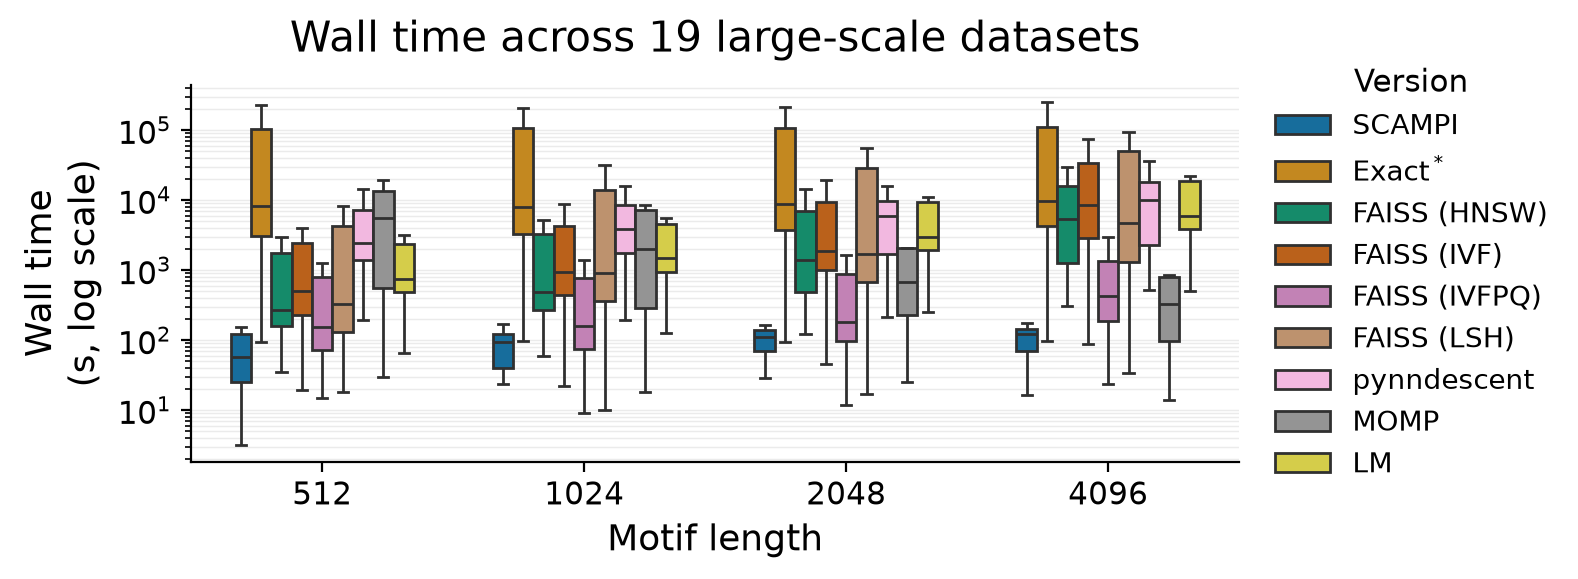

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_df, all_x, all_versions, missing = get_missing_combinations(
    df=filtered_df,
    x_col="motif length",
    hue_col="version",
    y_col="time in s",
    x_order=sorted(filtered_df["motif length"].dropna().unique()),
    hue_order=version_order,
)

# Create this once and reuse it for every plot
base_palette = sns.color_palette(
    "colorblind",
    n_colors=len(all_versions),
)

version_colors = dict(zip(all_versions, base_palette))

box_width = 0.7

sns.boxplot(
    data=plot_df,
    x="motif length",
    y="time in s",
    hue="version",
    order=all_x,
    hue_order=all_versions,
    # palette=palette,
    palette=version_colors,
    width=box_width,
    linewidth=1.0,
    showfliers=False,
    ax=ax,
)


ax.set_yscale("log")
ax.set_xlabel("Motif length", fontsize=13)
ax.set_ylabel("Wall time\n(s, log scale)", fontsize=13)

n_datasets = filtered_df["dataset"].nunique()
ax.set_title(
    f"Wall time across {n_datasets} large-scale datasets",
    fontsize=15,
    pad=12,
)

ax.tick_params(axis="both", which="major", labelsize=11)
ax.grid(axis="y", which="both", linewidth=0.5, alpha=0.25)

add_missing_x_markers(
    ax=ax,
    missing=missing,
    x_order=all_x,
    hue_order=all_versions,
    group_width=box_width,
    y_fraction=0.03,
)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(
    handles=handles,
    labels=labels,
    title="Version",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=10,
    title_fontsize=11,
    frameon=False,
)


color_missing_legend_labels(
    legend=leg,
    missing=missing,
    color="red",
)

sns.despine(ax=ax)
fig.tight_layout()

fig.savefig(
    "images/boxplot_runtime.pdf",
    bbox_inches="tight",
)
plt.show()

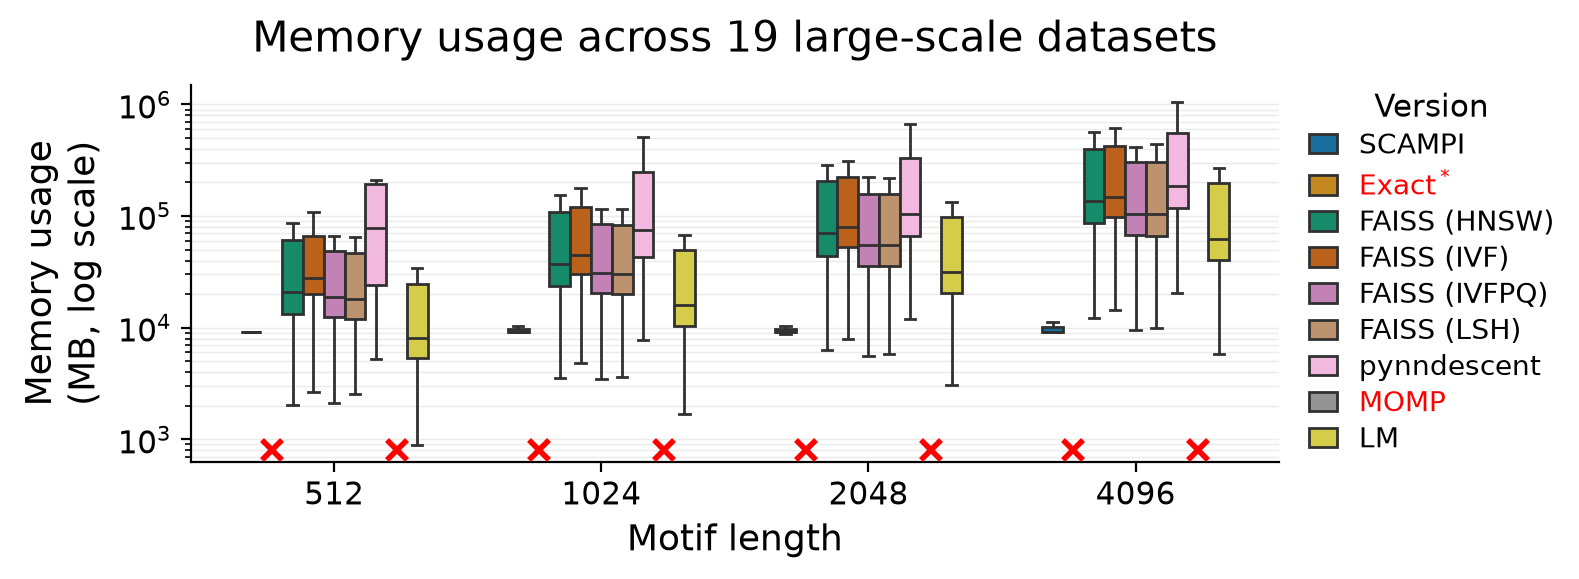

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_df, all_x, all_versions, missing = get_missing_combinations(
    df=filtered_df,
    x_col="motif length",
    hue_col="version",
    y_col="memory in MB",
    x_order=sorted(filtered_df["motif length"].dropna().unique()),
    hue_order=version_order,
)

box_width = 0.7

sns.boxplot(
    data=plot_df,
    x="motif length",
    y="memory in MB",
    hue="version",
    order=all_x,
    hue_order=all_versions,
    # palette=palette,
    palette=version_colors,
    width=box_width,
    linewidth=1.0,
    showfliers=False,
    ax=ax,
)

ax.set_yscale("log")

ax.set_xlabel("Motif length", fontsize=13)
ax.set_ylabel("Memory usage\n(MB, log scale)", fontsize=13)

n_datasets = filtered_df["dataset"].nunique()
ax.set_title(
    f"Memory usage across {n_datasets} large-scale datasets",
    fontsize=15,
    pad=12,
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
)

ax.grid(
    axis="y",
    which="both",
    linewidth=0.5,
    alpha=0.25,
)

add_missing_x_markers(
    ax=ax,
    missing=missing,
    x_order=all_x,
    hue_order=all_versions,
    group_width=box_width,
    y_fraction=0.03,
)

handles, labels = ax.get_legend_handles_labels()

leg = ax.legend(
    handles=handles,
    labels=labels,
    title="Version",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=10,
    title_fontsize=11,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.3,
    frameon=False,
)

color_missing_legend_labels(
    legend=leg,
    missing=missing,
    color="red",
)

sns.despine(ax=ax)
fig.tight_layout()

fig.savefig(
    "images/boxplot_memory.pdf",
    bbox_inches="tight",
)

plt.show()

In [8]:
filtered_df.dropna(subset="memory in MB") \
    .pivot_table(
        values=["memory in MB"], 
        index=["version"], 
        columns=["motif length"], 
        aggfunc='median')

memory in MB                             
motif length          512      1024      2048      4096
version                                                
FAISS (HNSW)       21045.0  37465.2   70240.1  135821.2
FAISS (IVF)        28114.0  44878.3   80435.7  149138.7
FAISS (IVFPQ)      18680.9  30999.8   55583.9  104793.6
FAISS (LSH)        17900.6  30341.2   55195.4  104970.3
LM                  8104.7  15894.5   31418.3   62392.5
SCAMPI              9160.3   9160.3    9164.9    9170.5
pynndescent        78005.6  75546.2  105078.6  187356.1

In [9]:
filtered_df.dropna(subset="relative extent") \
    .pivot_table(
        values=["relative extent"],
        index=["version"],
        columns=["motif length"], 
        aggfunc='mean')

relative extent                  
motif length             512   1024  2048  4096
version                                        
FAISS (HNSW)             94.8  90.0  76.5  73.9
FAISS (IVF)              94.8  84.8  76.5  65.9
FAISS (IVFPQ)            93.3  80.5  69.4  59.8
FAISS (LSH)              84.4  89.2  89.6  77.9
MOMP                      9.5  14.6  15.3  29.9
SCAMPI                   94.1  92.9  90.1  94.7
pynndescent              90.1  85.5  76.5  78.4

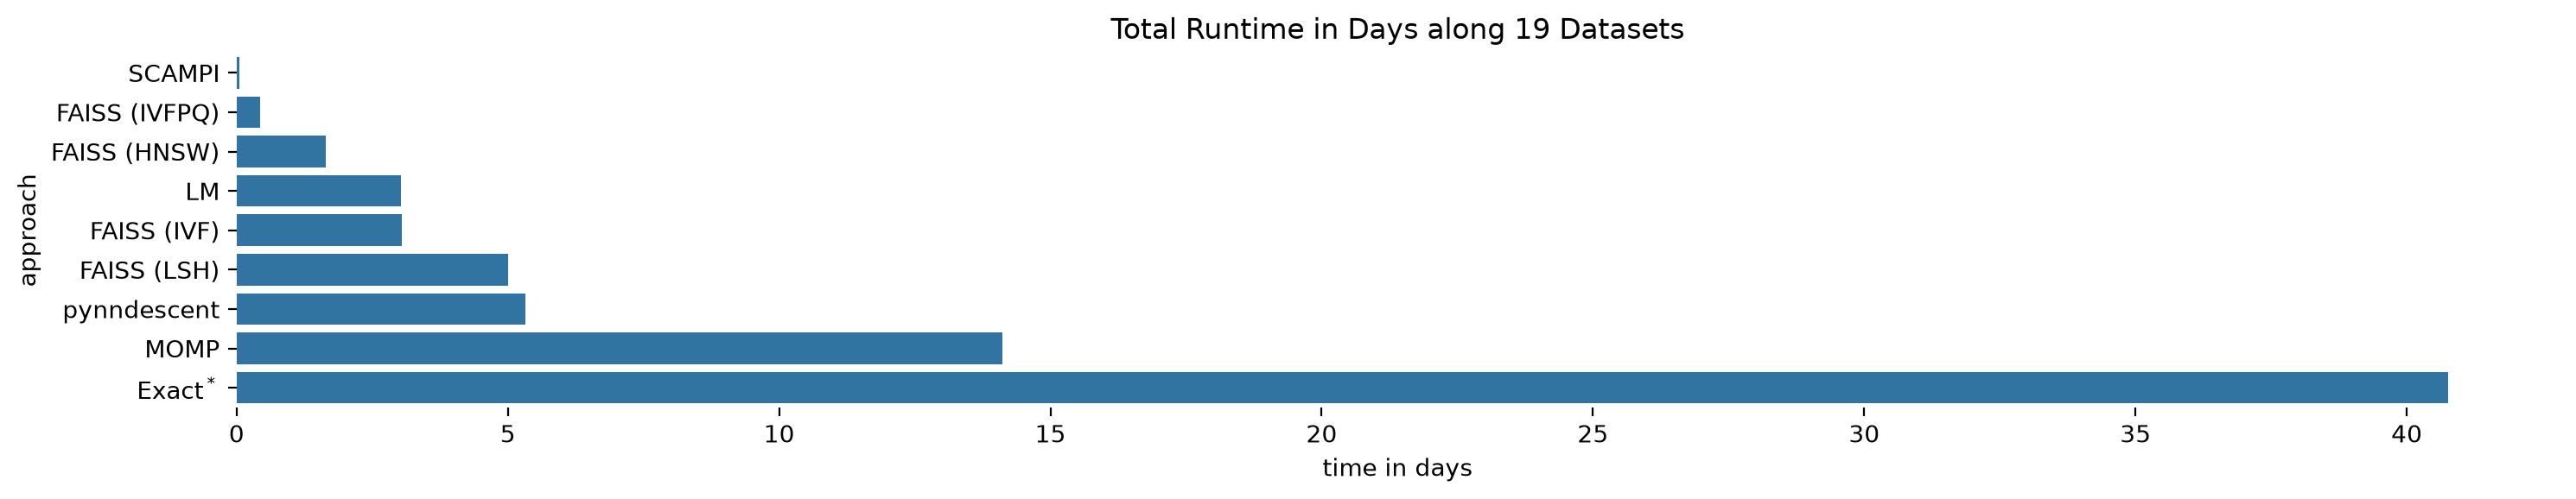

In [10]:
subset = filtered_df.copy().dropna(subset="time in s")
subset = subset[subset["motif length"]<4096]
subset["time in s"] = subset["time in s"] / 3600 / 24
subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
subset = subset.groupby("approach").agg({"time in days":"sum"})
order = subset.sort_values("time in days").index

plt.subplots(figsize=(15,3))
sns.barplot(y="approach", x="time in days", data=subset, order = order)
sns.despine(top=True, left=True, right=True, bottom=True)

# display(subset[["time in days"]])

plt.title(f"Total Runtime in Days along {filtered_df.dataset.nunique()} Datasets")
plt.tight_layout()
plt.savefig("images/all_runtime.pdf", bbox_inches='tight')
plt.show()

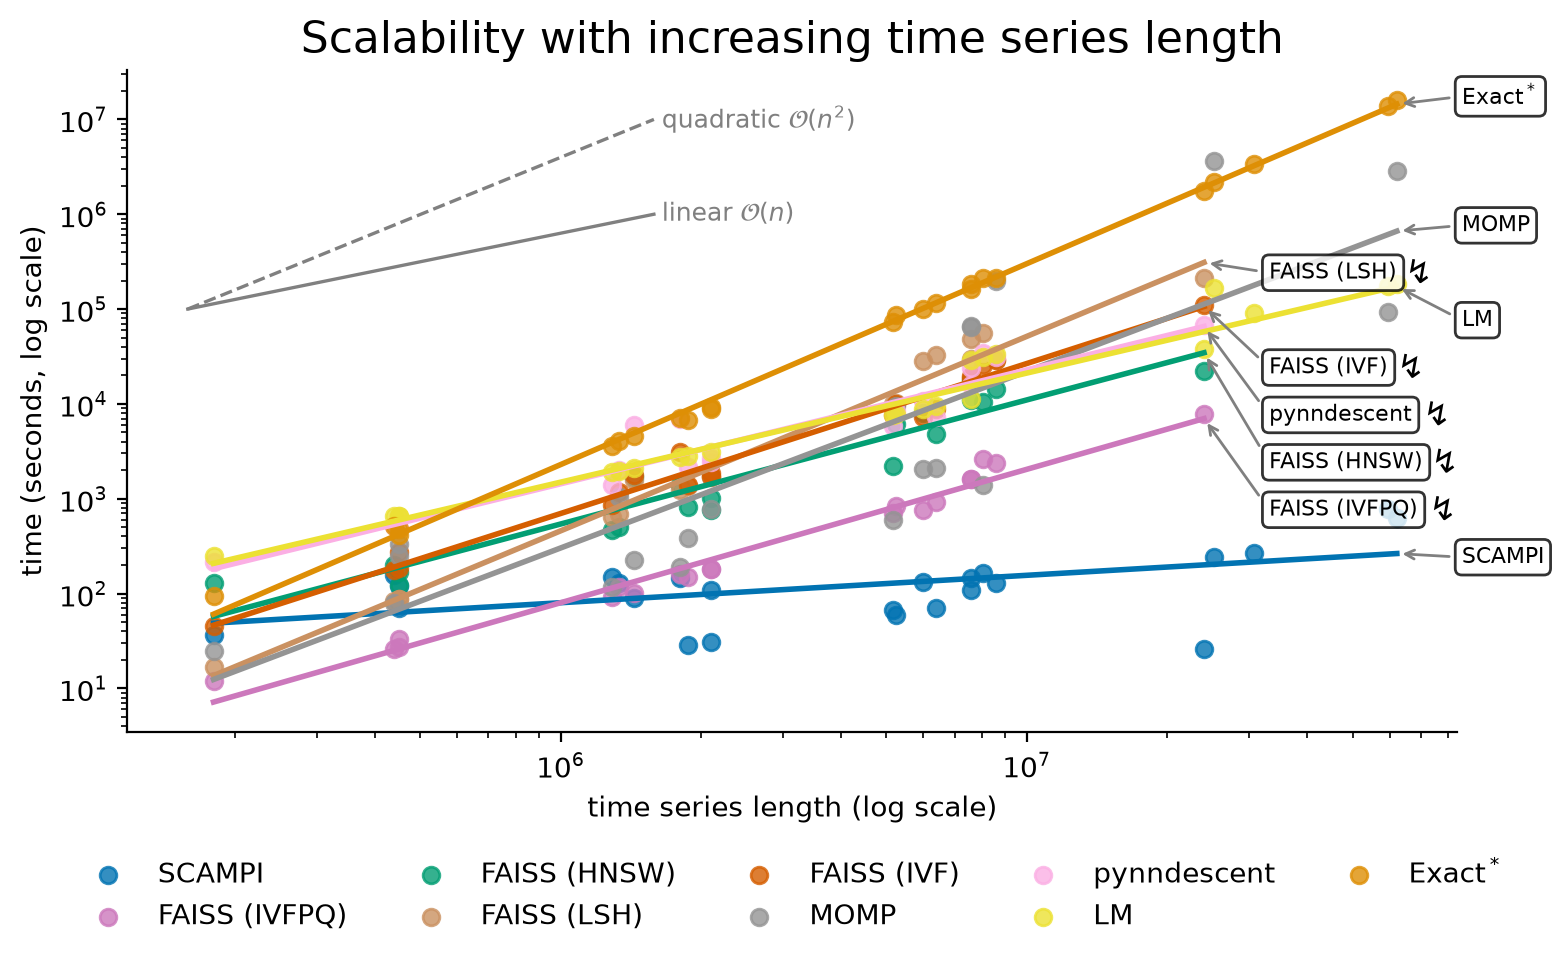

In [11]:
custom_order = [
    "SCAMPI",
    "FAISS (IVFPQ)",
    "FAISS (HNSW)",
    "FAISS (LSH)",
    "FAISS (IVF)",
    "MOMP",
    "pynndescent",
    "LM",
    "Exact$^*$",
]

subset = df_all.copy()
subset = subset[subset["motif length"] == 2048]
subset = subset[subset["version"].isin(custom_order)].copy()

subset["log length"] = np.log10(subset["length"].astype(np.float64))
subset["log time in s"] = np.log10(subset["time in s"].astype(np.float64))

# palette = sns.color_palette("tab10", n_colors=len(custom_order))

fig, ax = plt.subplots(figsize=(8, 5))

line_endpoints = {}

for order in custom_order:
    df_order = subset[subset["version"] == order].copy()
    if df_order.empty:
        continue

    color = version_colors[order]
    fit_reg = len(df_order) >= 2

    n_lines_before = len(ax.lines)

    sns.regplot(
        data=df_order,
        x="log length",
        y="log time in s",
        label=order,
        ci=None,
        scatter=True,
        fit_reg=fit_reg,
        robust=fit_reg,
        truncate=True,
        scatter_kws={"color": color},
        line_kws={"color": color, "linewidth": 2},
        ax=ax,
    )

    if fit_reg and len(ax.lines) > n_lines_before:
        line = ax.lines[-1]
        xdata, ydata = line.get_data()
        line_endpoints[order] = (xdata[-1], ydata[-1])
    else:
        last = df_order.sort_values("length").iloc[-1]
        line_endpoints[order] = (
            float(last["log length"]),
            float(last["log time in s"]),
        )

annotations = [
    (y, x, order)
    for order, (x, y) in line_endpoints.items()
]

annotations.sort(reverse=True)

spacing = 0.5
last_y = np.inf
texts = []

# Make sure limits exist before using them for annotation offsets
fig.canvas.draw()
xrange_ = ax.get_xlim()[1] - ax.get_xlim()[0]

for y, x, label in annotations:
    annoty = last_y - spacing if (last_y - y) < spacing else y
    last_y = annoty

    text = ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + 0.05 * xrange_, annoty),
        ha="left",
        fontsize=8,
        color="black",
        weight="normal",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        arrowprops=dict(arrowstyle="->", color="gray", relpos=(0.0, 0.5)),
    )
    texts.append(text)

# Y-axis ticks
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([fr"$10^{{{int(t)}}}$" for t in yticks])

minor_yticks = []
for major in yticks[:-1]:
    if np.isfinite(major):
        minor_yticks.extend(np.log10(np.arange(2, 10) * 10 ** major))
ax.set_yticks(minor_yticks, minor=True)
ax.set_yticklabels([], minor=True)

# X-axis ticks
xticks = [5, 6, 7, 8]
ax.set_xticks(xticks)
ax.set_xticklabels([fr"$10^{{{t}}}$" for t in xticks])

minor_xticks = []
for major in xticks[:-1]:
    minor_xticks.extend(np.log10(np.arange(2, 10) * 10 ** major))
ax.set_xticks(minor_xticks, minor=True)
ax.set_xticklabels([], minor=True)

sns.despine(top=True, left=False, right=True)

ax.set_title("Scalability with increasing time series length", fontsize=16)
ax.set_xlabel("time series length (log scale)")
ax.set_ylabel("time (seconds, log scale)")

# Use only one ncol argument
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=min(len(custom_order), 5),
    frameon=False,
)

# Reference slope lines
anchor_x, anchor_y = 5.2, 5.0
dx = 1.0

# Linear: slope 1
ax.plot(
    [anchor_x, anchor_x + dx],
    [anchor_y, anchor_y + dx],
    color="gray",
    linewidth=1.2,
    linestyle="-",
)
ax.text(
    anchor_x + dx,
    anchor_y + dx,
    r" linear $\mathcal{O}(n)$",
    va="center",
    ha="left",
    fontsize=9,
    color="gray",
)

# Quadratic: slope 2
ax.plot(
    [anchor_x, anchor_x + dx],
    [anchor_y, anchor_y + 2 * dx],
    color="gray",
    linewidth=1.2,
    linestyle="--",
)
ax.text(
    anchor_x + dx,
    anchor_y + 2 * dx,
    r" quadratic $\mathcal{O}(n^2)$",
    va="center",
    ha="left",
    fontsize=9,
    color="gray",
)

plt.tight_layout()

# Add markers after rendering so bbox is available
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

for text in ax.texts:
    if text.get_text().startswith("FAISS") or text.get_text() == "pynndescent":
        bbox_display = text.get_window_extent(renderer=renderer)
        bbox_data = ax.transData.inverted().transform(bbox_display)

        # Safer than emoji for PDF export
        ax.text(
            bbox_data[1, 0],
            bbox_data[0, 1] + 0.1,
            # r" $\lightning$",
            " ↯",
            ha="left",
            va="center",
            fontsize=12,
        )

plt.savefig("images/scalability.pdf", bbox_inches="tight")
plt.show()

,approach,time in days,extent,speedup
6,SCAMPI,2.5e-02,15.6,1.0
7,pynndescent,2.8e+00,15.8,111.9
1,FAISS (HNSW),3.0e+00,16.9,119.5
5,MOMP,5.3e+00,28.4,212.6
2,FAISS (IVF),5.8e+00,16.9,232.6
3,FAISS (LSH),6.8e+00,16.0,272.7
4,LM,7.5e+00,NaN,300.2
0,Exact$^*$,3.7e+01,NaN,1475.2


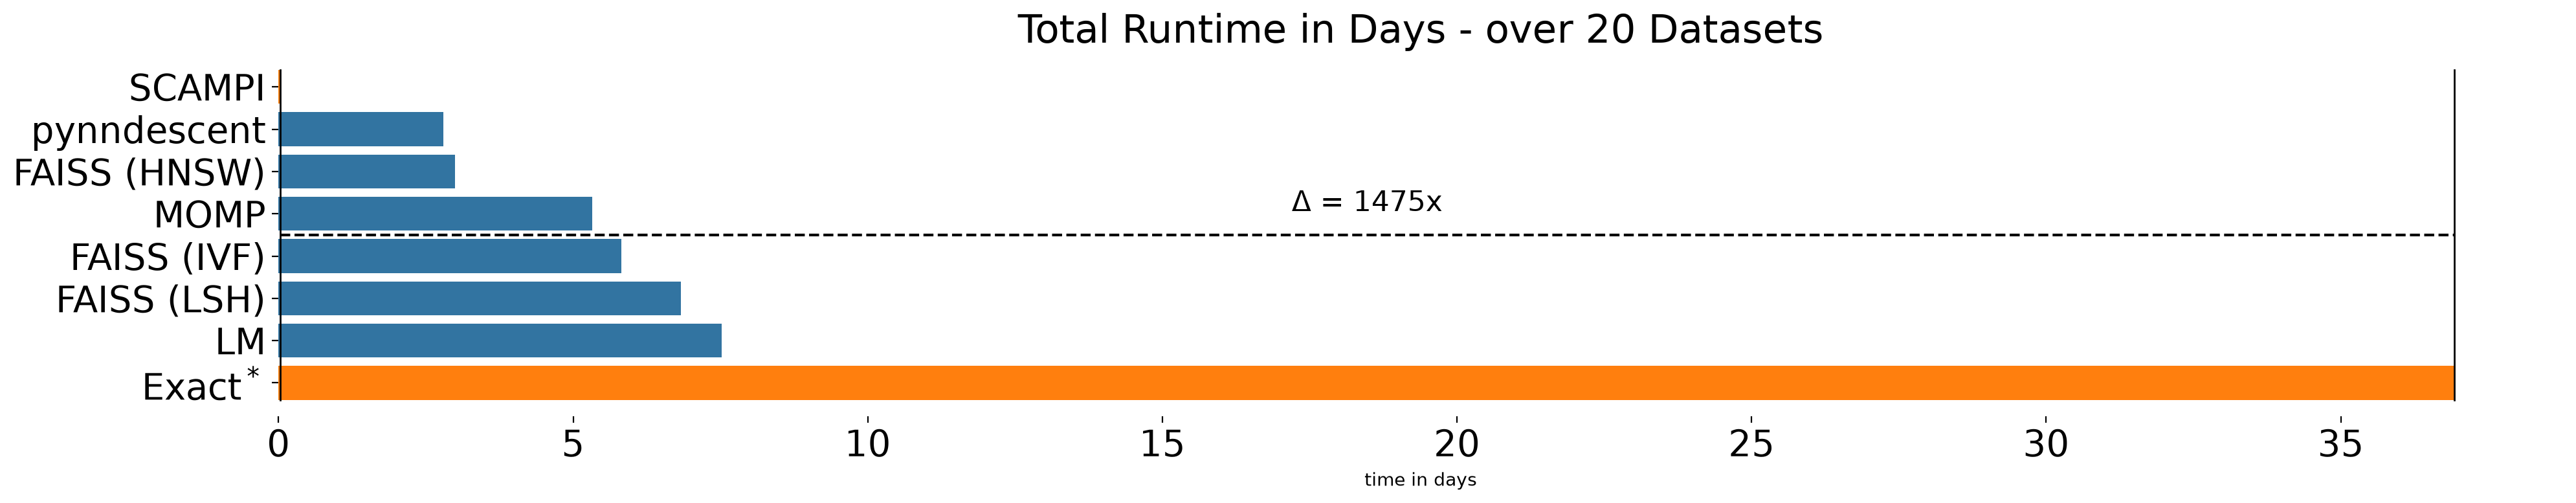

In [12]:
custom_order = [
    "SCAMPI",
    "FAISS (HNSW)",
    "FAISS (LSH)",
    "FAISS (IVF)",
    "pynndescent",
    "MOMP",
    "LM",
    "Exact$^*$",
]

def plot(datasets, length=4096):
    filtered_df = df_all.loc[
        df_all["dataset"].isin(datasets)
        & df_all["version"].isin(custom_order)
        & (df_all["motif length"] == length)
    ].copy()

    subset = (
        filtered_df
        .assign(**{"time in days": filtered_df["time in s"] / 86400})
        .rename(columns={"version": "approach"})
        .groupby("approach", as_index=False)
        .agg(
            **{
                "time in days": ("time in days", "sum"),
                "extent": ("extent", "median"),
            }
        )
        .sort_values("time in days")
    )

    subset["speedup"] = subset["time in days"] / subset["time in days"].min()

    fig, ax = plt.subplots(figsize=(20, 4))

    sns.barplot(
        data=subset,
        y="approach",
        x="time in days",
        order=subset["approach"],
        ax=ax,
    )

    sns.despine(ax=ax, top=True, left=True, right=True, bottom=True)

    # Highlight fastest and slowest
    bars = ax.patches
    first_bar, last_bar = bars[0], bars[-1]

    first_bar.set_facecolor("#ff7f0e")
    last_bar.set_facecolor("#ff7f0e")

    v1 = first_bar.get_width()
    v2 = last_bar.get_width()

    y_bottom = first_bar.get_y()
    y_top = last_bar.get_y() + last_bar.get_height()
    y_center = (y_bottom + y_top) / 2

    ax.plot(
        [v1, v2], [y_center, y_center],
        color="black", linestyle="--", linewidth=1.5,
    )
    ax.plot(
        [v1, v1], [y_bottom, y_top],
        color="black", linewidth=1,
    )
    ax.plot(
        [v2, v2], [y_bottom, y_top],
        color="black", linewidth=1,
    )

    factor = subset["time in days"].max() / subset["time in days"].min()

    ax.text(
        (v1 + v2) / 2,
        y_center - 0.4,
        f"Δ = {factor:.0f}x",
        ha="center",
        va="bottom",
        fontsize=16,
    )

    display(subset.sort_values("speedup"))

    n_datasets = filtered_df["dataset"].nunique()

    ax.set(
        ylabel="",
        title=(
            f"Total Runtime in Days - over {n_datasets} Datasets"
            if len(datasets) > 1
            else f"Runtime in Days - {datasets[0]}"
        ),
    )

    ax.tick_params(axis="both", labelsize=20)
    ax.title.set_fontsize(22)

    fig.tight_layout()

plot(datasets_to_keep)
plt.savefig("images/runtime_total.pdf", bbox_inches='tight')
plt.show()


In [13]:
# df_all[(df_all.version == "Exact$^*$") & (df_all.length > 10**6)].sort_values("length")# ["time in s"] # / 3600 #  / 24

,approach,time in days,extent,speedup
0,SCAMPI,3.4e-04,3.4e-02,1.0
1,MOMP,5.3e-01,9.1e+01,1587.7
2,FAISS (HNSW),6.6e-01,2.6e+01,1976.0
3,FAISS (IVF),1.3e+00,2.6e+01,3837.5
4,LM,1.8e+00,NaN,5255.5
5,Exact$^*$,2.2e+01,NaN,65266.2


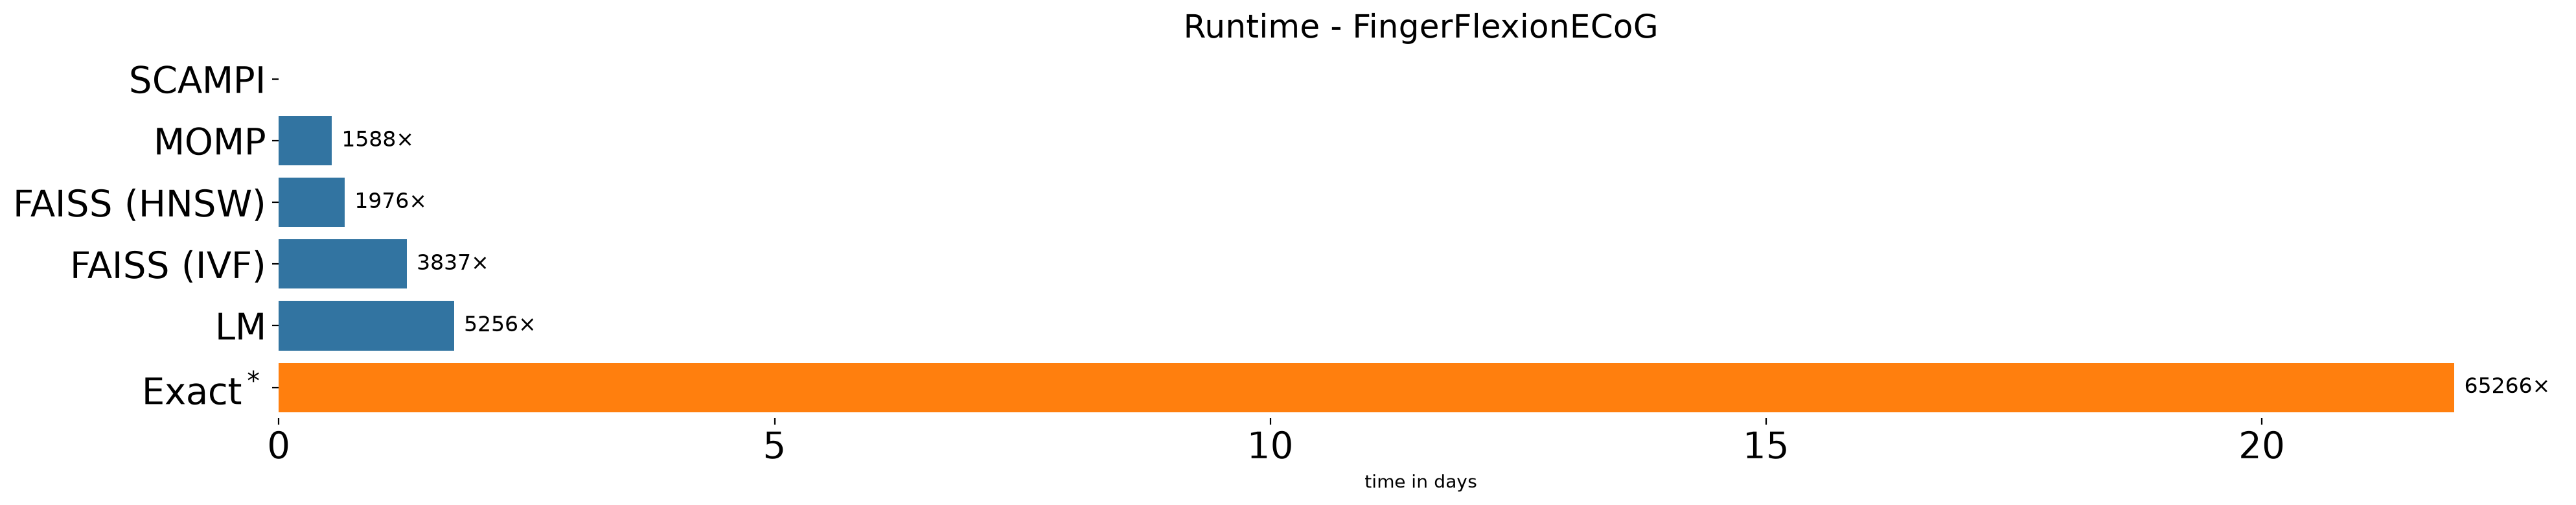

In [14]:
custom_order = [
    "SCAMPI",
    "FAISS (HNSW)",
    "FAISS (LSH)",
    "FAISS (IVF)",
    "FAISS (IVFPQ)",
    "pynndescent",
    "MOMP",
    "LM",
    "Exact$^*$",
]

def plot2(datasets, length=4096):
    filtered_df = df_all.loc[
        df_all["dataset"].isin(datasets)
        & df_all["version"].isin(custom_order)
        & (df_all["motif length"] == length)
    ].copy()

    subset = (
        filtered_df
        .assign(**{"time in days": filtered_df["time in s"] / 86400})
        .rename(columns={"version": "approach"})
        .groupby("approach", as_index=False)
        .agg(
            **{
                "time in days": ("time in days", "sum"),
                "extent": ("extent", "median"),
            }
        )
        .sort_values("time in days")
        .reset_index(drop=True)
    )

    # Relative to fastest method
    subset["speedup"] = (
        subset["time in days"] / subset["time in days"].min()
    )

    fig, ax = plt.subplots(figsize=(20, 4))

    sns.barplot(
        data=subset,
        y="approach",
        x="time in days",
        order=subset["approach"],
        ax=ax,
    )

    sns.despine(ax=ax, top=True, left=True, right=True, bottom=True)

    # Highlight fastest + slowest
    ax.patches[0].set_facecolor("#ff7f0e")
    ax.patches[-1].set_facecolor("#ff7f0e")

    # Annotate all except fastest
    for bar, speed in zip(ax.patches[1:], subset["speedup"].iloc[1:]):
        ax.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{speed:.0f}×",
            va="center",
            ha="left",
            fontsize=12,
        )

    display(subset)

    n_datasets = filtered_df["dataset"].nunique()

    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=20)

    ax.set_title(
        (
            f"Total Runtime in Days - over {n_datasets} Datasets"
            if len(datasets) > 1
            else f"Runtime - {datasets[0]}"
        ),
        fontsize=18,
    )

    fig.tight_layout()

plot2(["FingerFlexionECoG"], length=4096)
plt.savefig("images/FingerFlexionECoG.pdf", bbox_inches='tight')
plt.show()